<a href="https://colab.research.google.com/github/cristianzucconi2-web/iatoarts/blob/main/iatoarts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installiamo mido per gestire i file MIDI
!pip install mido
import random
import mido
from mido import Message, MidiFile, MidiTrack

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00


In [2]:
# Le note della scala di Do Maggiore
SCALA = [60, 62, 64, 65, 67, 69, 71, 72]
LUNGHEZZA_MELODIA = 16  # Quante note è lunga una canzone
DIMENSIONE_POPOLAZIONE = 100 # Quante canzoni creiamo a ogni giro

In [3]:
def crea_individuo():
    # Crea una lista di 16 note a caso dalla scala
    return [random.choice(SCALA) for _ in range(LUNGHEZZA_MELODIA)]

# Creiamo le prime 100 canzoni
popolazione = [crea_individuo() for _ in range(DIMENSIONE_POPOLAZIONE)]

# Vediamo com'è fatta la prima canzone
print("Esempio di melodia casuale (Individuo 0):")
print(popolazione[0])

Esempio di melodia casuale (Individuo 0):
[69, 71, 65, 71, 65, 67, 69, 65, 62, 71, 65, 71, 67, 65, 64, 71]


In [4]:
def calcola_fitness(melodia):
    voto = 100 # Partiamo da 100
    for i in range(len(melodia) - 1):
        distanza = abs(melodia[i] - melodia[i+1])
        # Se il salto è più di 4 note, togliamo punti
        if distanza > 4:
            voto -= 10
        # Se le note sono vicine (salto di 1 o 2), diamo un bonus
        if distanza <= 2:
            voto += 5
    return voto

# Testiamo il voto sulla prima canzone
voto_test = calcola_fitness(popolazione[0])
print(f"Il voto della prima canzone è: {voto_test}")

Il voto della prima canzone è: 55


In [5]:
def evoluzione(popolazione_attuale):
    # 1. Calcoliamo il voto per tutti e ordiniamo dal migliore al peggiore
    popolazione_ordinata = sorted(popolazione_attuale, key=calcola_fitness, reverse=True)

    # 2. Teniamo solo i "top 20" (i sopravvissuti)
    migliori = popolazione_ordinata[:20]
    nuova_generazione = migliori.copy() # I migliori passano intatti al prossimo giro

    # 3. Creiamo i figli finché non torniamo a 100 canzoni
    while len(nuova_generazione) < DIMENSIONE_POPOLAZIONE:
        padre = random.choice(migliori)
        madre = random.choice(migliori)

        # CROSSOVER: Taglio a metà
        punto_taglio = LUNGHEZZA_MELODIA // 2
        figlio = padre[:punto_taglio] + madre[punto_taglio:]

        # MUTAZIONE: 10% di probabilità di cambiare una nota a caso
        if random.random() < 0.1:
            indice_nota = random.randint(0, LUNGHEZZA_MELODIA - 1)
            figlio[indice_nota] = random.choice(SCALA)

        nuova_generazione.append(figlio)

    return nuova_generazione

In [6]:
# Facciamo evolvere la popolazione per 100 generazioni
for g in range(100):
    popolazione = evoluzione(popolazione)
    miglior_voto = calcola_fitness(popolazione[0])
    if g % 20 == 0: # Stampiamo ogni 20 giri
        print(f"Generazione {g}: Miglior voto = {miglior_voto}")

# La melodia finale è la prima della lista (la migliore)
melodia_finale = popolazione[0]
print("\nMelodia Finale Ottimizzata:")
print(melodia_finale)
print(f"Voto finale: {calcola_fitness(melodia_finale)}")

Generazione 0: Miglior voto = 130
Generazione 20: Miglior voto = 175
Generazione 40: Miglior voto = 175
Generazione 60: Miglior voto = 175
Generazione 80: Miglior voto = 175

Melodia Finale Ottimizzata:
[65, 64, 65, 65, 67, 67, 65, 64, 62, 62, 64, 65, 65, 64, 62, 60]
Voto finale: 175


In [7]:
def salva_midi(melodia, nome_file="canzone_ai.mid"):
    mid = MidiFile()
    track = MidiTrack()
    mid.tracks.append(track)

    for nota in melodia:
        # Note On: suona la nota (volume 80)
        track.append(Message('note_on', note=nota, velocity=80, time=0))
        # Note Off: ferma la nota dopo 480 tick (un quarto)
        track.append(Message('note_off', note=nota, velocity=80, time=480))

    mid.save(nome_file)
    print(f"File {nome_file} creato! Scaricalo dalla cartella a sinistra di Colab.")

salva_midi(melodia_finale)

File canzone_ai.mid creato! Scaricalo dalla cartella a sinistra di Colab.


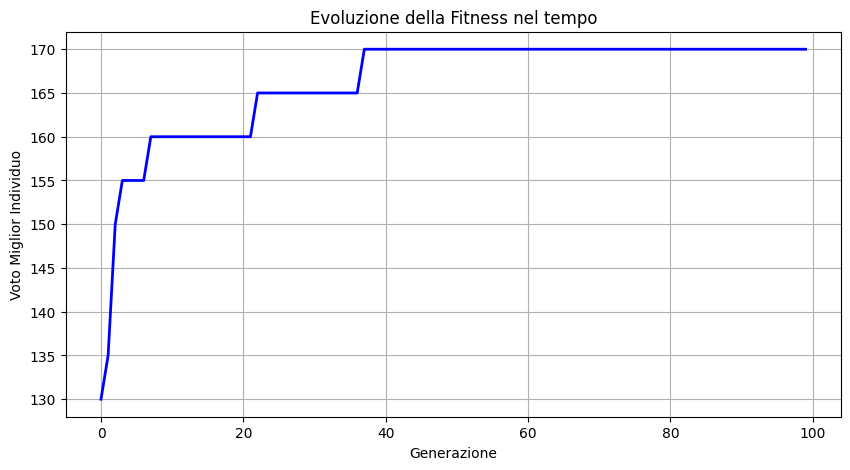

In [8]:
import matplotlib.pyplot as plt

# Creiamo una lista per memorizzare i progressi
storia_fitness = []
popolazione = [crea_individuo() for _ in range(DIMENSIONE_POPOLAZIONE)]

for g in range(100):
    popolazione = evoluzione(popolazione)
    miglior_voto = calcola_fitness(popolazione[0])
    storia_fitness.append(miglior_voto)

# Disegniamo il grafico
plt.figure(figsize=(10, 5))
plt.plot(storia_fitness, color='blue', linewidth=2)
plt.title("Evoluzione della Fitness nel tempo")
plt.xlabel("Generazione")
plt.ylabel("Voto Miglior Individuo")
plt.grid(True)
plt.show()